# boreal dynamics multiple

In [4]:
import numpy as np
import rasterio
from scipy import stats
import matplotlib.pyplot as plt
import multiprocessing as mp
from functools import partial
import os
from tqdm import tqdm
import time

In [5]:
def process_single_raster(raster_path, num_simulations=50, random_seed=None):
    """
    Process a single raster to perform Monte Carlo simulations
    
    Parameters:
    -----------
    raster_path : str
        Path to the 2-band raster file
    num_simulations : int
        Number of Monte Carlo simulations to run
    random_seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    dict
        Dictionary with simulation results for this raster
    """
    if random_seed is not None:
        np.random.seed(random_seed)
        
    # Open the raster file
    with rasterio.open(raster_path) as src:
        # Read band 1 (means) and band 2 (standard deviations)
        mean_band = src.read(1)
        std_band = src.read(2)
        
    # Perform Monte Carlo simulations
    all_simulations = np.zeros(num_simulations)
    
    for i in range(num_simulations):
        # Generate random samples based on normal distribution for each pixel
        random_sample = np.random.normal(loc=mean_band, scale=std_band)
        # Calculate sum for this simulation, ignoring NaN values
        all_simulations[i] = np.nansum(random_sample)
    
    # Calculate statistics for this raster
    mean_sum = np.mean(all_simulations)
    std_sum = np.std(all_simulations, ddof=1)
    
    # Calculate total variance for this raster (sum of squared standard deviations)
    total_variance = np.nansum(np.square(std_band))
    
    return {
        'raster_path': raster_path,
        'mean_sum': mean_sum,
        'std_sum': std_sum,
        'total_variance': total_variance,
        'simulation_sums': all_simulations
    }

def process_multiple_rasters(raster_paths, num_simulations=50, n_cores=None):
    """
    Process multiple rasters in parallel, combining their results.
    
    Parameters:
    -----------
    raster_paths : list
        List of paths to raster files
    num_simulations : int
        Number of Monte Carlo simulations to run
    n_cores : int
        Number of cores to use (defaults to all available cores - 1)
        
    Returns:
    --------
    dict
        Dictionary with combined results
    """
    if n_cores is None:
        n_cores = max(1, mp.cpu_count() - 1)
    
    print(f"Processing {len(raster_paths)} rasters using {n_cores} cores...")
    
    # Create a pool of worker processes
    pool = mp.Pool(processes=n_cores)
    
    # Use the same random seeds for reproducibility
    random_seeds = np.random.randint(0, 10000, size=len(raster_paths))
    
    # Set up the parallel execution with different seeds for each process
    process_func = partial(process_single_raster, num_simulations=num_simulations)
    tasks = [(path, seed) for path, seed in zip(raster_paths, random_seeds)]
    
    # Execute processing in parallel with progress bar
    results = []
    with tqdm(total=len(tasks), desc="Processing rasters") as pbar:
        for task in tasks:
            result = pool.apply_async(process_func, args=(task[0],), 
                                     kwds={'random_seed': task[1]},
                                     callback=lambda _: pbar.update())
            results.append(result)
        
        # Close the pool and wait for all processes to finish
        pool.close()
        pool.join()
    
    # Collect results
    raster_results = [res.get() for res in results]
    
    # Combine results across all rasters
    combined_mean_sum = sum(result['mean_sum'] for result in raster_results)
    
    # For the combined variance of the sum, add variances (since areas are independent)
    combined_variance = sum(result['std_sum']**2 for result in raster_results)
    combined_std = np.sqrt(combined_variance)
    
    # Standard error for the combined sum
    combined_sem = combined_std / np.sqrt(num_simulations)
    
    # Critical t-value for 95% confidence
    t_value = stats.t.ppf(0.975, num_simulations - 1)
    
    # 95% confidence interval for the combined sum
    combined_ci_lower = combined_mean_sum - t_value * combined_sem
    combined_ci_upper = combined_mean_sum + t_value * combined_sem
    
    # Calculate combined prediction interval
    # Sum the total variance from all rasters for prediction interval
    total_pred_variance = sum(result['total_variance'] for result in raster_results)
    combined_pred_std = np.sqrt(total_pred_variance + combined_sem**2)
    
    # 95% prediction interval
    combined_pi_lower = combined_mean_sum - t_value * combined_pred_std
    combined_pi_upper = combined_mean_sum + t_value * combined_pred_std
    
    # Store all simulation sums for visualization (optional)
    all_simulation_sums = np.array([result['simulation_sums'] for result in raster_results])
    
    return {
        'raster_results': raster_results,
        'combined_mean_sum': combined_mean_sum,
        'combined_std': combined_std,
        'combined_ci_lower': combined_ci_lower,
        'combined_ci_upper': combined_ci_upper,
        'combined_pi_lower': combined_pi_lower,
        'combined_pi_upper': combined_pi_upper,
        'all_simulation_sums': all_simulation_sums
    }

def visualize_combined_results(combined_results, output_dir='.'):
    """
    Visualize the combined results from multiple rasters
    
    Parameters:
    -----------
    combined_results : dict
        Output from process_multiple_rasters
    output_dir : str
        Directory to save output files
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Get data for plotting
    raster_results = combined_results['raster_results']
    
    # Plot individual raster sums
    plt.figure(figsize=(12, 8))
    labels = [os.path.basename(res['raster_path']) for res in raster_results]
    means = [res['mean_sum'] for res in raster_results]
    stds = [res['std_sum'] for res in raster_results]
    
    # Plot individual raster results
    x = range(len(labels))
    plt.bar(x, means, yerr=stds, capsize=5, alpha=0.7)
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.ylabel('Sum Value')
    plt.title('Sum by Raster with Error Bars (± 1 SD)')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'individual_raster_sums.png'), dpi=300)
    
    # Plot combined results
    plt.figure(figsize=(10, 6))
    
    # Create a simple bar chart for the combined sum
    plt.bar(['Combined Total'], [combined_results['combined_mean_sum']], 
            yerr=[combined_results['combined_std']], capsize=5, 
            alpha=0.7, color='steelblue')
    
    # Add confidence and prediction intervals
    plt.errorbar(['Combined Total'], [combined_results['combined_mean_sum']], 
                yerr=[[combined_results['combined_mean_sum'] - combined_results['combined_ci_lower']], 
                      [combined_results['combined_ci_upper'] - combined_results['combined_mean_sum']]], 
                fmt='o', color='green', capsize=10, label='95% Confidence Interval')
    
    plt.errorbar(['Combined Total'], [combined_results['combined_mean_sum']], 
                yerr=[[combined_results['combined_mean_sum'] - combined_results['combined_pi_lower']], 
                      [combined_results['combined_pi_upper'] - combined_results['combined_mean_sum']]], 
                fmt='o', color='red', capsize=15, label='95% Prediction Interval')
    
    plt.ylabel('Sum Value')
    plt.title('Combined Sum with Confidence and Prediction Intervals')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'combined_sum.png'), dpi=300)
    
    # Print combined statistics
    print("\nCombined Statistics:")
    print(f"Mean Sum: {combined_results['combined_mean_sum']:.2f}")
    print(f"Standard Deviation: {combined_results['combined_std']:.2f}")
    print(f"95% Confidence Interval: ({combined_results['combined_ci_lower']:.2f}, {combined_results['combined_ci_upper']:.2f})")
    print(f"95% Prediction Interval: ({combined_results['combined_pi_lower']:.2f}, {combined_results['combined_pi_upper']:.2f})")


In [7]:
import s3fs
s3 = s3fs.S3FileSystem(anon=True)

In [8]:
from rastoolslib import *

In [11]:
import sys
sys.path.append('/projects/code/icesat2_boreal/lib')

In [13]:
import mosaiclib

Processing 2 rasters using 2 cores...


Processing rasters: 100%|██████████| 2/2 [00:28<00:00, 14.01s/it]


Processing completed in 28.04 seconds

Combined Statistics:
Mean Sum: 706894707.43
Standard Deviation: 29683.34
95% Confidence Interval: (706886271.52, 706903143.34)
95% Prediction Interval: (706834005.79, 706955409.07)


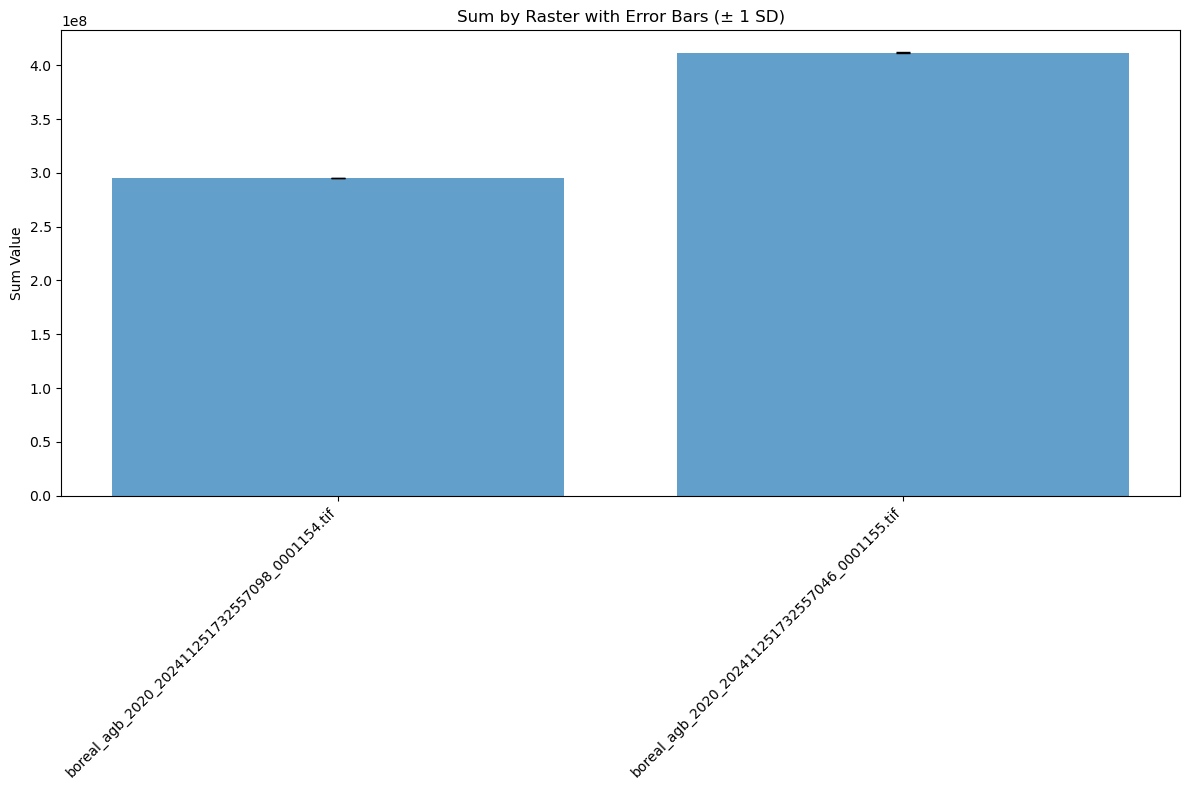

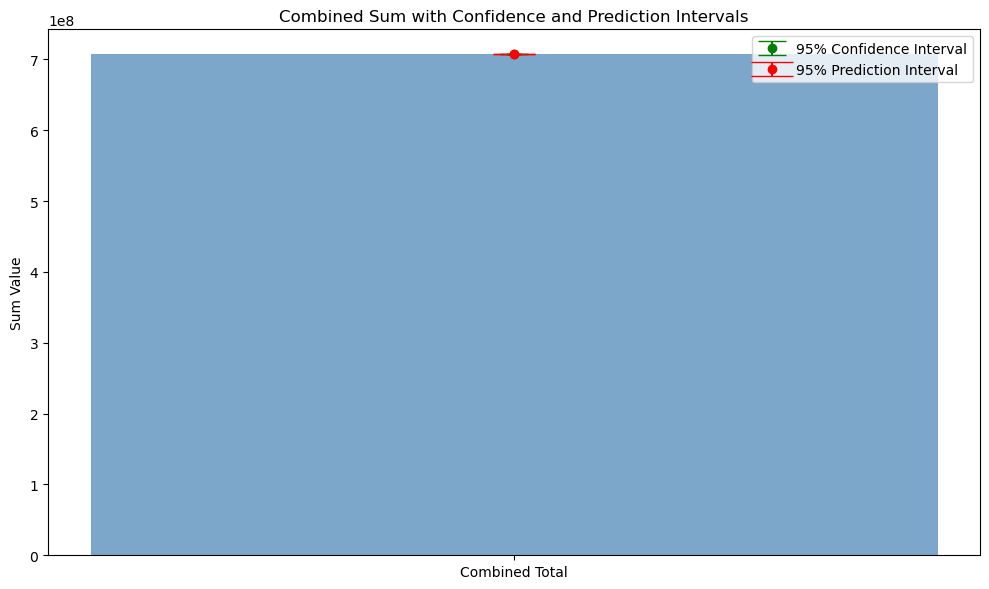

In [15]:
# List of raster files to process
raster_paths = [
    get_cog_s3_path(1154, mosaiclib.AGB_TINDEX_FN_DICT['2020_v2.1']),
    get_cog_s3_path(1155, mosaiclib.AGB_TINDEX_FN_DICT['2020_v2.1']),
    # Add more rasters as needed
]

# Number of simulations to run
num_simulations = 50

# Number of cores to use (optional, defaults to CPU count - 1)
n_cores = 2  # set a specific number or leave as None

# Process rasters in parallel
start_time = time.time()
combined_results = process_multiple_rasters(raster_paths, num_simulations, n_cores)
elapsed_time = time.time() - start_time

print(f"Processing completed in {elapsed_time:.2f} seconds")

# Output directory for visualizations
output_dir = "raster_analysis_results"

# Visualize results
visualize_combined_results(combined_results, output_dir)